In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [38]:
resume_df = pd.read_csv(r"D:\resume\Resume\Resume.csv")

In [39]:
resume_df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [40]:
resume_df.shape

(2484, 4)

In [41]:
resume_df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [42]:
resume_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [43]:
resume_df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

In [44]:
resume_df['Resume_str'] = resume_df['Resume_str'].str.replace(r'[^a-zA-Z\s]','',regex=True)

In [45]:
print(resume_df['Resume_str'].iloc[0])

         HR ADMINISTRATORMARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with  years of experience in Hospitality and Customer Service Management   Respected builder and leader of customerfocused teams strives to instill a shared enthusiastic commitment to customer service         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multitasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ     Micros    Opera PMS    Fidelio    OPERA    Reservation System ORS    Holidex    Completed courses and seminars in customer service sales strategies inventory control loss prevention safety time 

In [46]:
resume_df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATORMARKETING ASSOCIATE\n...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,HR SPECIALIST US HR OPERATIONS ...,"<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over ...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


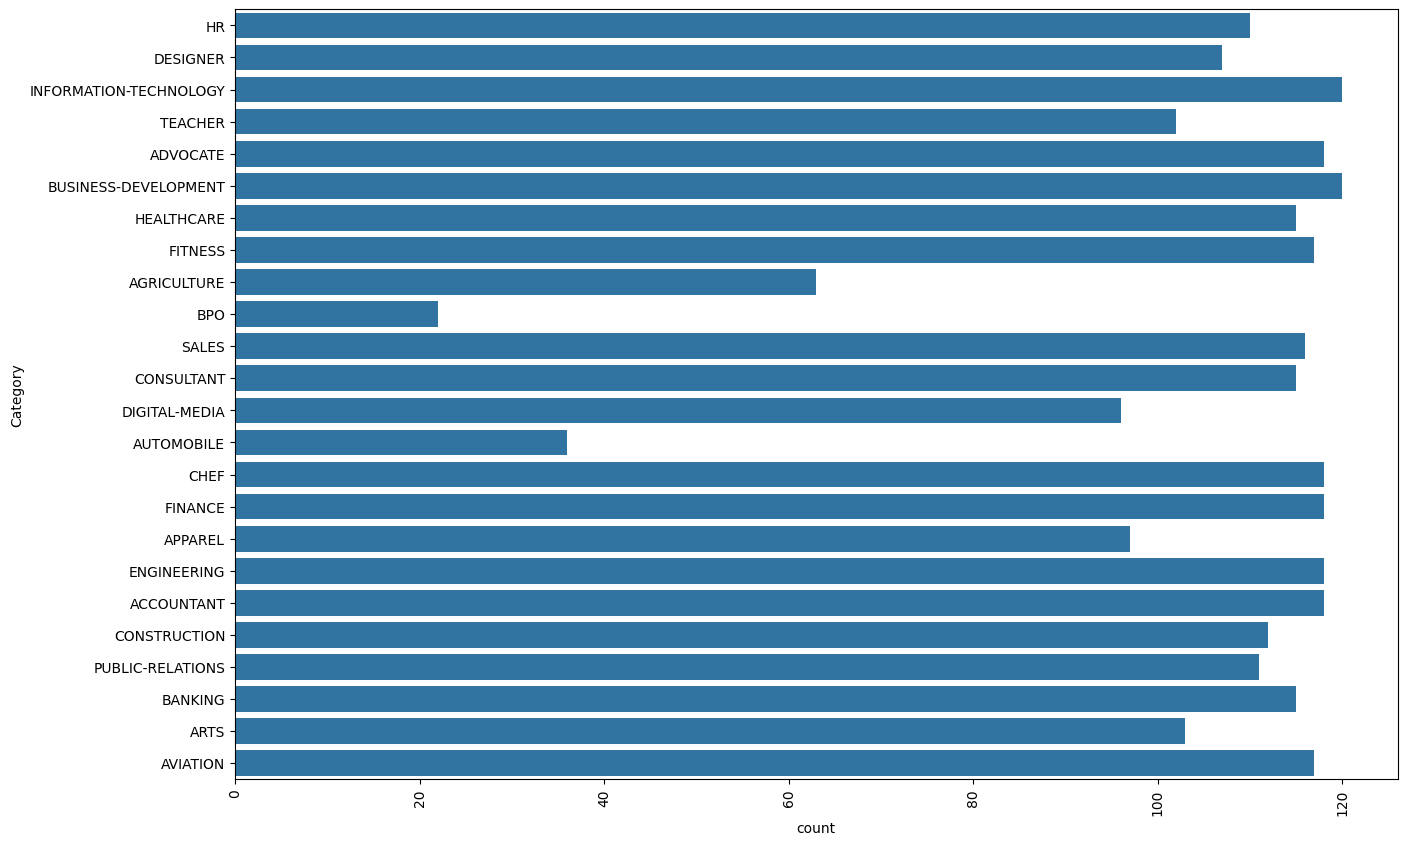

In [47]:
plt.figure(figsize=(15,10))
sns.countplot(resume_df['Category'])
plt.xticks(rotation=90)
plt.show()

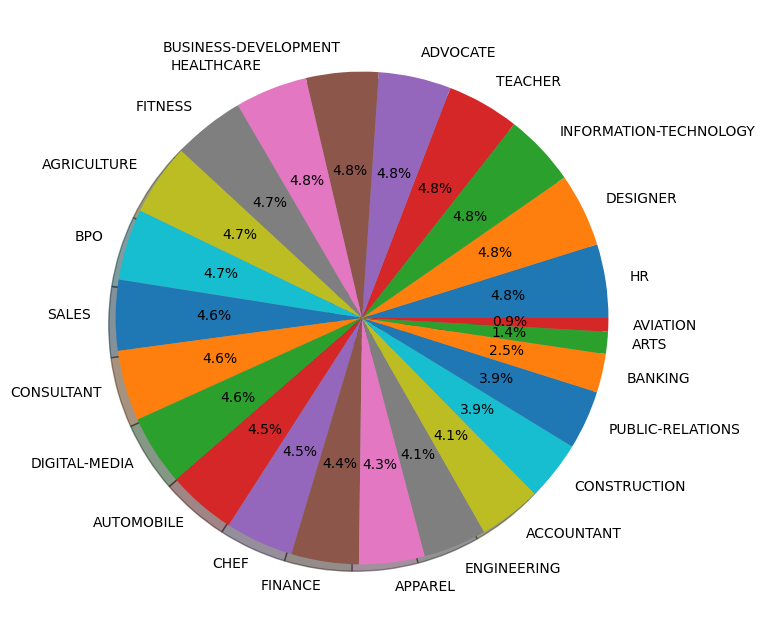

In [48]:
counts = resume_df['Category'].value_counts()
labels = resume_df['Category'].unique()
plt.figure(figsize=(10,8))
plt.pie(counts,labels=labels, autopct='%1.1f%%', shadow=True)
plt.show()


In [49]:
resume_df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [50]:
from sklearn.utils import resample

# Define the maximum counts among all categories
max_count = resume_df['Category'].value_counts().max()

# Oversample minority classes to match the maximum count
balance_data = []
for category in resume_df['Category'].unique():
    category_data=resume_df[resume_df['Category'] == category]
    if len(category_data) < max_count:
        balanced_category_data = resample(category_data, replace=True, n_samples=max_count, random_state=42)
    else:
        balanced_category_data = resample(category_data, replace=False, n_samples=max_count, random_state=42)
    balance_data.append(balanced_category_data)  
# Concatenate the balanced data for all categories
balanced_df = pd.concat(balance_data)

In [51]:
balanced_df['Category'].value_counts()

Category
HR                        120
DESIGNER                  120
ARTS                      120
BANKING                   120
PUBLIC-RELATIONS          120
CONSTRUCTION              120
ACCOUNTANT                120
ENGINEERING               120
APPAREL                   120
FINANCE                   120
CHEF                      120
AUTOMOBILE                120
DIGITAL-MEDIA             120
CONSULTANT                120
SALES                     120
BPO                       120
AGRICULTURE               120
FITNESS                   120
HEALTHCARE                120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  120
TEACHER                   120
INFORMATION-TECHNOLOGY    120
AVIATION                  120
Name: count, dtype: int64

In [52]:
balanced_df.isnull().sum()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

In [53]:
X = balanced_df['Resume_str']
y = balanced_df['Category']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [54]:
print(X_train)

228              DIRECTOR OF INFORMATION TECHNOLOGY   ...
1577             FINANCE  OFFICE MANAGER       Summary...
1149             CONSULTANT           Summary     I co...
951                EXECUTIVE DIRECTOR         Professi...
2152             ASSOCIATE INVESTMENT BANKING OPERATIO...
                              ...                        
1337             ORGANIZATION DEVELOPMENT CONSULTANT  ...
992              RISK SPECIALIST       Professional Su...
983              TRANSACTION PROCESSING ANALYST       ...
1037             SALES SPECIALIST           Objective ...
844              MECHANICAL DESIGN ENGINEER INTERN    ...
Name: Resume_str, Length: 2304, dtype: object


In [55]:
#converting text data into numerical features using TF-IDF vectorization


In [56]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf=tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf= tfidf_vectorizer.transform(X_test)

In [57]:
print(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 795771 stored elements and shape (2304, 37407)>
  Coords	Values
  (0, 9522)	0.026105783646370912
  (0, 22936)	0.20184592818916613
  (0, 16392)	0.023646261105664583
  (0, 33297)	0.07125064055116474
  (0, 26255)	0.013959032703438134
  (0, 26285)	0.016103996956432675
  (0, 30105)	0.04811271975928498
  (0, 26365)	0.26820665717434183
  (0, 19630)	0.10918299341996848
  (0, 25408)	0.012409376887591002
  (0, 19682)	0.024894866890009824
  (0, 36766)	0.02688327481709407
  (0, 23651)	0.02995379011921918
  (0, 37229)	0.018324180103286142
  (0, 9805)	0.01673984193733997
  (0, 12012)	0.01096536866350487
  (0, 16171)	0.039654725743343305
  (0, 14859)	0.1263362101417314
  (0, 4889)	0.06985364202717152
  (0, 26040)	0.03439201262348502
  (0, 29900)	0.04537671705828926
  (0, 19064)	0.012974154553951242
  (0, 1568)	0.2811557846977996
  (0, 31864)	0.0055017578844402575
  (0, 14159)	0.03132898521945832
  :	:
  (2303, 17896)	0.03986024469383454
  

In [58]:
print(X_test_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 198130 stored elements and shape (576, 37407)>
  Coords	Values
  (0, 69)	0.013941649677279164
  (0, 133)	0.08021908050561734
  (0, 288)	0.015425218995533594
  (0, 316)	0.03479381932465651
  (0, 320)	0.021469548019924414
  (0, 324)	0.025745737431735076
  (0, 379)	0.01814761368316869
  (0, 413)	0.03661808456351885
  (0, 421)	0.03592013029110861
  (0, 468)	0.02840514880172279
  (0, 511)	0.03746827268983547
  (0, 514)	0.022402194288545396
  (0, 602)	0.025786051696103495
  (0, 759)	0.024818909017464637
  (0, 776)	0.02471826858510537
  (0, 1197)	0.023223761180521996
  (0, 1485)	0.02940875445232775
  (0, 1500)	0.02423080699733864
  (0, 1545)	0.01816534855938726
  (0, 1568)	0.34237156216317416
  (0, 1943)	0.027491908353644512
  (0, 2066)	0.014464360192432118
  (0, 2221)	0.01437916593272176
  (0, 2302)	0.04083256941657748
  (0, 2336)	0.01950509345750071
  :	:
  (575, 35076)	0.026989461964368668
  (575, 35144)	0.04068773351934142
  (5

In [59]:
#train the model using random forest classifier

In [60]:
rf_classifier= RandomForestClassifier()
rf_classifier.fit(X_train_tfidf, y_train)
y_pred = rf_classifier.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8385416666666666


In [61]:
print(classification_report(y_test, y_pred))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.76      0.95      0.84        20
              ADVOCATE       0.92      0.76      0.83        29
           AGRICULTURE       0.95      0.91      0.93        23
               APPAREL       0.74      0.77      0.76        22
                  ARTS       0.94      0.62      0.75        24
            AUTOMOBILE       1.00      0.68      0.81        19
              AVIATION       0.97      1.00      0.98        28
               BANKING       0.88      0.68      0.77        22
                   BPO       1.00      1.00      1.00        15
  BUSINESS-DEVELOPMENT       0.45      0.50      0.47        18
                  CHEF       0.84      0.96      0.90        28
          CONSTRUCTION       0.96      1.00      0.98        25
            CONSULTANT       0.96      0.77      0.86        31
              DESIGNER       0.80      0.86      0.83        28
         DIGITAL-MEDIA       0.82      

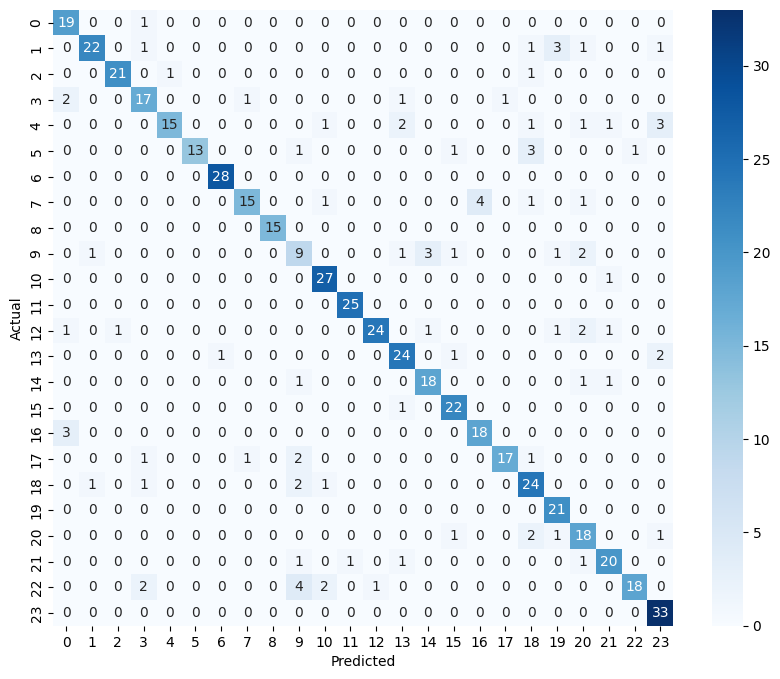

In [62]:
conf_matrix= confusion_matrix(y_test,y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix, annot=True,fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

create predictive system

In [63]:
from importlib.resources import open_text
import re
def predict_category(resume_text):
   # resume_text = open_text(resume_text)
    resume_tfidf = tfidf_vectorizer.transform([resume_text])
    predicted_category= rf_classifier.predict(resume_tfidf)
    return predicted_category[0]


testing prediction_1


In [64]:
resume_file = '''REGISTERED CLIENT SERVICE ASSOCIATE
Summary
To obtain a position where my years of experience in the client support environment and proven track record of maintaining and developing new
businesses can be fuly utilized. Results-oriented, high-energy, hands-on professional, with a successful record of accomplishments in client
support. Major strengths include strong leadership, excelent communication skils, strong team player, a tention to detail, compliance in al
regulated environment and supervisory skils.
Skils
Microsoft Word for Windows, Excel, Power Point, Access, Adobe PageMaker 6.5, Adobe Photoshop, Dreamweaver, Visio, Unix, Oracle 9i
and Developer 2000.
Experience
Registered Client Service Associate 06/2012 to Current Company Name City , State
Serve as primary contact to investment clients and prospects.
Provide al operational services and support for client accounts.
Provide Financial Advisors with presentations and seminars, aide in the implementation of marketing materials for prospects.
Referring clients to other lines of banking division to enhance the relationship.
Work with Financial Advisors to e ficiently manage their book of business to increase their revenue for the bank.
Conduct monthly audits to make sure that client objectives are in consideration with the investments being o fered by the brokers.
Work directly with the Financial Advisors to manage their book of business worth 40 milion.
Relationship Banker II 06/2004 to 06/2012 Company Name City , State
Serve as primary contact to retail, commercial, and prospect clients.
New account opening and cross sale of other banking products and services.
Referring identified client needs to other lines of banking divisions.'''

predicted_category = predict_category(resume_file)
print("Predicted Category:", predicted_category)

Predicted Category: BANKING


testing prediction_2

In [65]:
resume_file = '''Administrative aviation logistics professional with 26 years' experience working in the military sector including 20 years' operating in a supervisory
position. Tracked and managed U.S. Navy and Marine Corps aeronautical logistics assets performing above and beyond the requirements of the
Military Occupational Specialty (6046/6047). Additional roles include management, personnel development, and quality assurance. Outstanding
leader and team builder; established and managed programs; coached and mentored personnel. Exceptional technical and technology skils. BA in
Human Resources Management
'''
predicted_category = predict_category(resume_file)
print("Predicted Category is : " , predicted_category)

Predicted Category is :  AVIATION


testing prediction_3

In [66]:
resume_file = ''' Senior Software Executive Senior Software Executive who is a key contributor to strategic planning and product development. Highly skiled at
creating and implementing key software improvements and process changes by uncovering major process limitations, maximizing profitability,
scalability, and competition in the global marketplace. Accomplishments (over last 15 years +) Reported directly to C-level executives and Board
members, successfuly bridging the gap between the business and Engineering, implementing strategic plans and ensuring that the engineering teams
are aligned to business goals. Agile expert and evangelist, running software development teams for over 17 years and specificaly agile software
development for more that 13 years. Reorganized and transitioned many teams and companies to become smooth running agile groups, drasticaly
reducing delivery issues, making the work very transparent, empowering team members to become self-directed and accountable to their
commitments. Skiled at managing entire software development process and employees including QA, Project Management, Technical Support, on
and o fshore teams, contractors, subsidiaries, and merger/acquisitions. Successfuly on-boarded the engineers and technology from an acquired
company and quickly merged their intelectual property (IP) into the main product line. Advocate for strong Engineering Best Practices, including
design & code reviews, paired programming, unit tests and continuous integration testing through automation. Including, establishing leading and
trailing engineering metrics, which provide strong indicators of product quality and delivery schedule. Managed globaly distributed teams ranging
from 15-60 people, with P&L responsibilities between $2M - $6M. Teams have been located in US, Germany, Hungary, Russia, China, and
Argentina. Consistently an early adopter of critical trends in methodologies and practices, which transform and refine processes to increase the
delivery of business value.
Skil Highlights
Technology Â· Java Â· Amazon AWS Â· Hibernate Â· PHP Â· EC2 Â· Elastic Search Â· C++ Â· JSMVC Â· JUnit Â· C Â· HTML Â·
Selenium Â· CanJS Â· CSS Â· Aurora Â· PL/SQL Â· Bootstrap Â· Jenkins Â· Oracle Â· Python Â· Phabricator Â· My/SQL Â· AJAX Â·
GitHub Â· JavaScript Â· Camel Â· Jira Â· REST and SOAP services Â· MongoDB Â· Perl
Professional Experience
Engineering Operations Director 
January 2014 to Current Company Name ï¼​ City , St
'''
predicted_category = predict_category(resume_file)
print("Predicted Category is : ", predicted_category)

Predicted Category is :  ENGINEERING


In [67]:
# store the model

In [68]:
import pickle
import os

os.makedirs('models', exist_ok=True)

pickle.dump(rf_classifier, open('models/rf_classifier_categorization.pkl', 'wb'))
pickle.dump(tfidf_vectorizer, open('models/tfidf_vectorizer_categorization.pkl', 'wb'))

In [69]:
import pickle

with open('models/tfidf_vectorizer_categorization.pkl', 'rb') as f:
    model = pickle.load(f)

print("Model loaded:", type(model))

Model loaded: <class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [71]:
from fastapi import FastAPI
import pickle
import os
import pickle
from pydantic import BaseModel

app = FastAPI()
@app.get("/")
def home():
    return {"message": "API is working"}


# Input schema
class ResumeFile(BaseModel):
    resume_text: str

# Load vectorizer
with open('Models/tfidf_vectorizer_categorization.pkl', 'rb') as f:
    tfidf_vectorizer = pickle.load(f)

# Load model
with open('Models/rf_classifier_categorization.pkl', 'rb') as f:
    rf_classifier = pickle.load(f)

# Create FastAPI app
app = FastAPI()

@app.post("/predict")
def predict_category(data: ResumeFile):
    resume_text = data.resume_text.replace("\n", " ")
    resume_tfidf = tfidf_vectorizer.transform([resume_text])
    prediction = rf_classifier.predict(resume_tfidf)
    
    return {"predicted_category": prediction[0]}





In [73]:
import streamlit as st
import requests

# FastAPI endpoint
API_URL = "http://127.0.0.1:8000"

st.set_page_config(page_title="Resume Screener", layout="centered")

st.title("📄 AI Resume Category Predictor")
st.write("Paste your resume text below and get the predicted category.")

# Input box
resume_text = st.text_area("Enter Resume Text", height=200)

# Button
if st.button("Predict Category"):
    if resume_text.strip() == "":
        st.warning("Please enter resume text")
    else:
        try:
            # Send request to FastAPI
            response = requests.post(
                API_URL,
                json={"resume_text": resume_text}
            )

            if response.status_code == 200:
                result = response.json()
                st.success(f"Predicted Category: {result['predicted_category']}")
            else:
                st.error("Error from API")

        except Exception as e:
            st.error(f"API not running ❌\nError: {e}")

2026-04-12 01:28:07.425 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 01:28:07.584 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 01:28:07.595 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 01:28:07.752 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 01:28:07.768 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 01:28:07.778 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 01:28:07.781 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 01:28:07.806 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar